# Multivariate Analysis

## Titanic Dataset

Multivariate Analysis is the process of studying relationships among three or more variables at the same time. It helps us understand how multiple features are connected and whether they show important patterns together.

In this notebook, we will analyze:

- Correlation Matrix
- Heatmap
- Pair Plot
- Multiple Feature Relationships
- Feature Interactions
- Numerical Feature Relationships

The main objective is to identify:

- Strong correlations
- Weak correlations
- Negative correlations
- Potential multicollinearity
- Interesting relationships between features

This analysis provides a deeper understanding of the dataset and can help during feature selection and Machine Learning model development.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Correlation Matrix

## Concept

A correlation matrix shows the relationship between multiple numerical variables. Correlation values range from -1 to 1.

- A value close to 1 indicates a strong positive relationship.
- A value close to -1 indicates a strong negative relationship.
- A value close to 0 indicates a weak linear relationship.

## Example

In a business dataset, income and spending may have a positive relationship, while product price and customer demand may have a negative relationship.

## Implementation

We will calculate the correlation matrix for the numerical variables in the Titanic dataset.

## Output

The output will display the correlation values between numerical features.

## Interpretation

Higher positive or negative values indicate stronger relationships between variables.

## Insight

The correlation matrix helps identify which numerical features may be related to each other.

## AI/ML Relevance

Correlation analysis helps during feature selection and can also help identify possible multicollinearity between input features.

In [2]:
numerical_columns = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numerical_columns.corr()

correlation_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


# 2. Correlation Heatmap

## Concept

A heatmap is a visual representation of a correlation matrix. It makes it easier to identify strong, weak, positive, and negative relationships between multiple variables.

## Example

Instead of reading many correlation values in a table, a heatmap provides a quick visual summary of feature relationships.

## Implementation

We will create a heatmap using the correlation matrix.

## Output

Each cell represents the correlation between two numerical variables.

## Interpretation

Values closer to 1 or -1 represent stronger relationships, while values closer to 0 represent weaker relationships.

## Insight

The heatmap provides a quick overview of the numerical relationships in the Titanic dataset.

## AI/ML Relevance

Heatmaps help identify correlated features and potential multicollinearity before building a Machine Learning model.

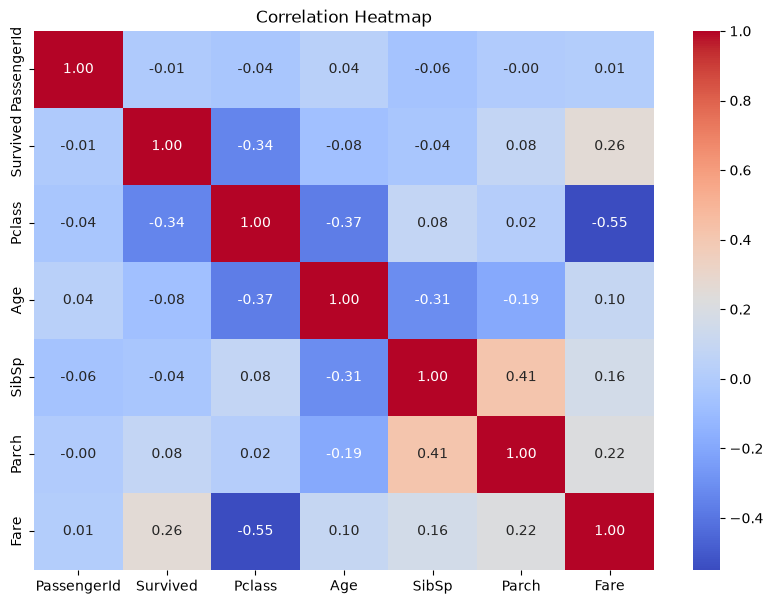

In [3]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# 3. Pair Plot

## Concept

A pair plot shows relationships between multiple numerical variables at the same time.

It usually displays:

- Scatter plots between pairs of variables
- Distribution plots for individual variables

## Example

In a business dataset, a pair plot can help compare income, spending, age, and purchase amount together.

## Implementation

We will create a pair plot using important numerical variables from the Titanic dataset.

## Output

The output will display multiple relationships in a single visualization.

## Interpretation

The scatter plots help identify possible relationships, patterns, and unusual observations.

## Insight

A pair plot makes it easier to explore multiple numerical variables together.

## AI/ML Relevance

Pair plots are useful during Exploratory Data Analysis because they help identify relationships and patterns before feature selection.

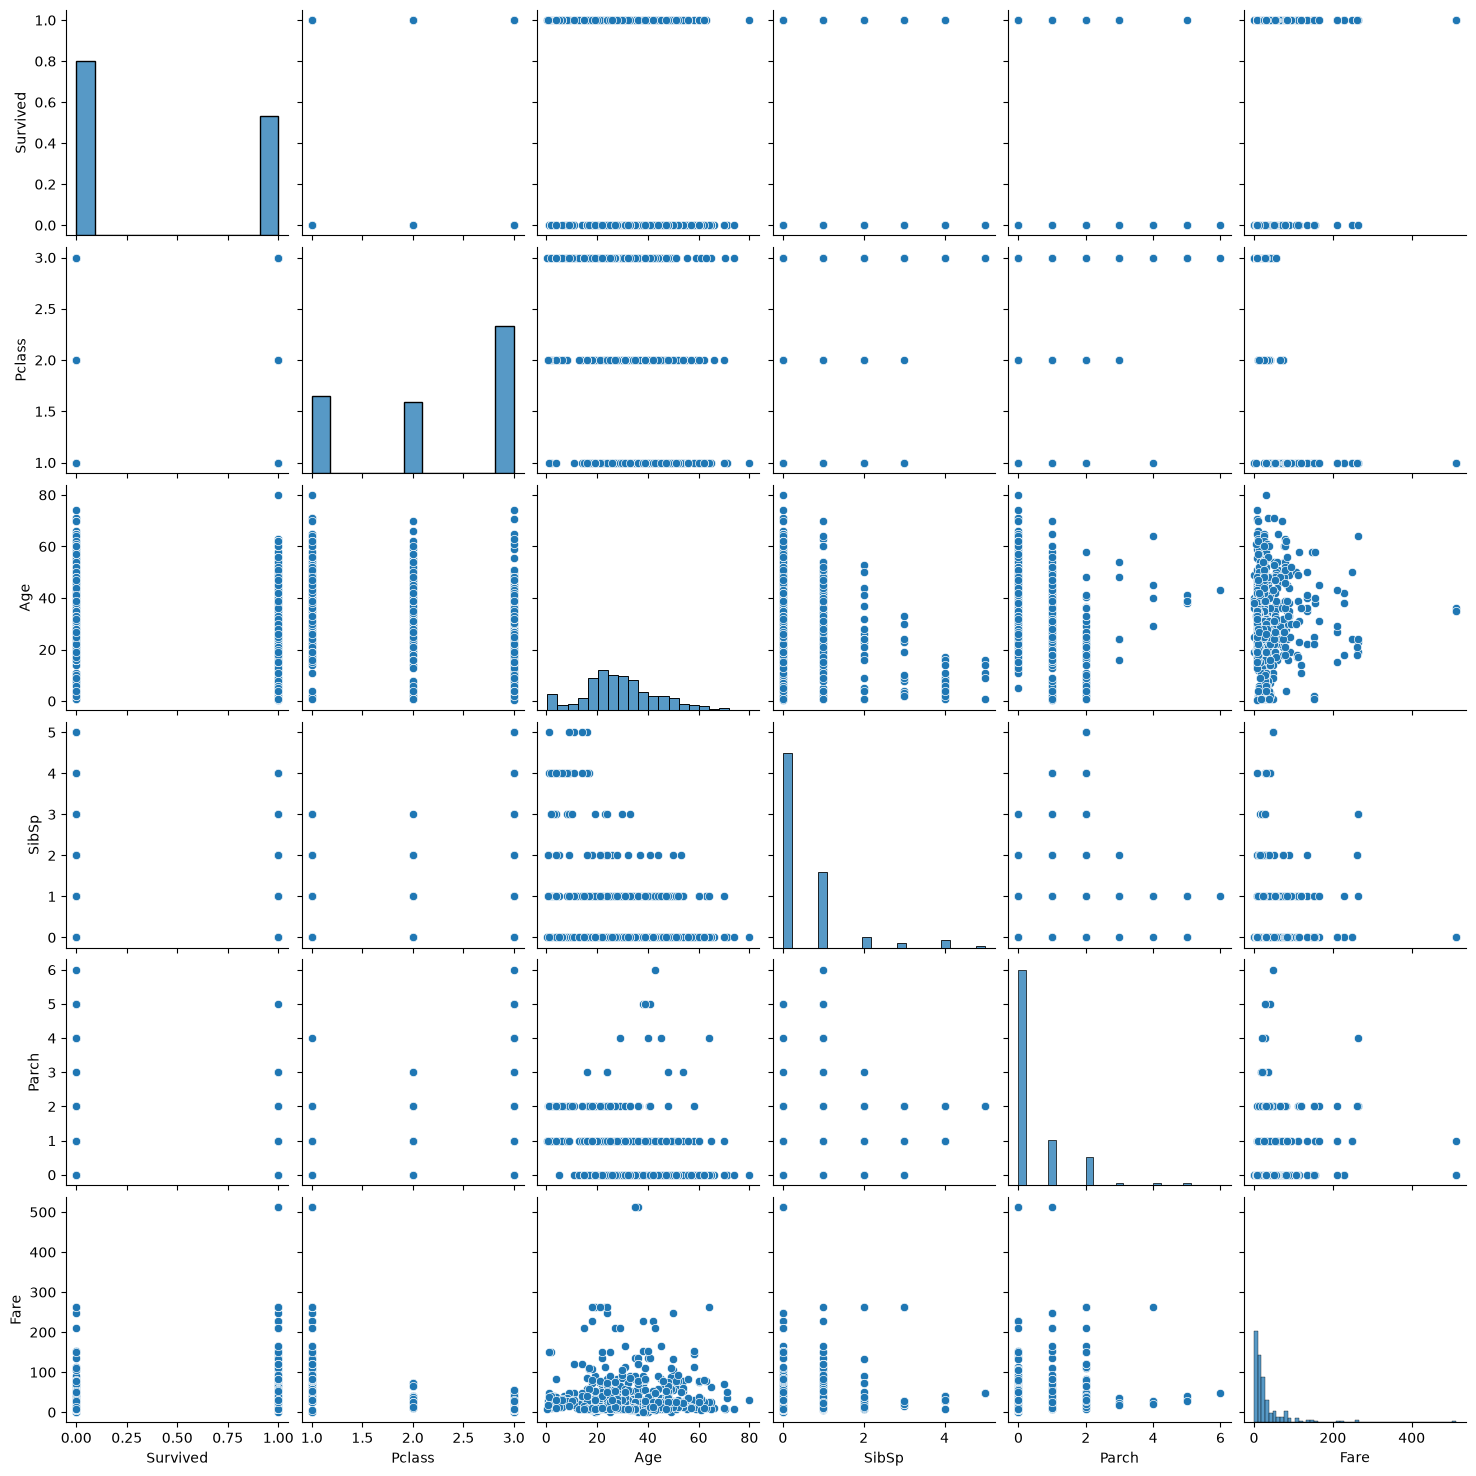

In [4]:
pairplot_columns = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

sns.pairplot(df[pairplot_columns].dropna())

plt.show()

# 4. Multiple Feature Relationships: Age, Fare and Survival

## Concept

Multivariate analysis can study more than two variables together.

In this analysis, we will examine:

- Age
- Fare
- Survival

## Example

In a business dataset, customer age, income, and purchase decision can be analyzed together.

Similarly, in the Titanic dataset, we can examine whether age and fare show different patterns for passengers who survived and those who did not survive.

## Implementation

We will use a scatter plot and include survival status as an additional category.

## Output

The plot will display Age and Fare while separating passengers based on survival status.

## Interpretation

Different patterns or groups may indicate that multiple features together provide more useful information than a single feature.

## Insight

The relationship between Age and Fare can be viewed together with the target variable, Survived.

## AI/ML Relevance

Machine Learning models often use multiple features together to predict an outcome. Multivariate analysis helps us understand these combined relationships.

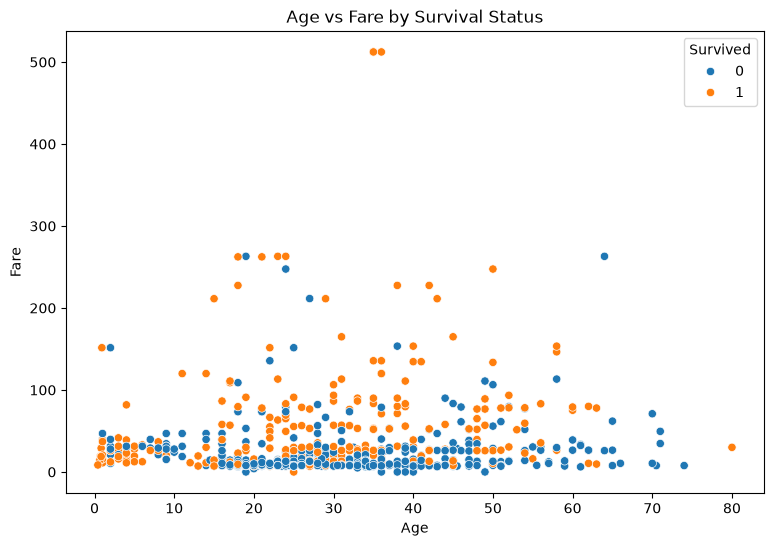

In [5]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

# 5. Feature Interaction: Sex, Passenger Class and Survival

## Concept

Feature interaction occurs when the relationship between one feature and the target may change depending on another feature.

## Example

In a business dataset, the relationship between income and purchasing behavior may be different for different customer age groups.

In the Titanic dataset, we can study how survival varies when both passenger sex and passenger class are considered together.

## Implementation

We will create a grouped bar chart using Sex, Passenger Class, and Survival.

## Output

The visualization will show how survival patterns differ across sex and passenger class.

## Interpretation

Different groups may have different survival rates, showing that the features can provide useful information together.

## Insight

Analyzing multiple categorical features together provides a deeper understanding than analyzing each feature separately.

## AI/ML Relevance

Feature interactions can improve predictive performance because models may learn relationships involving multiple features.

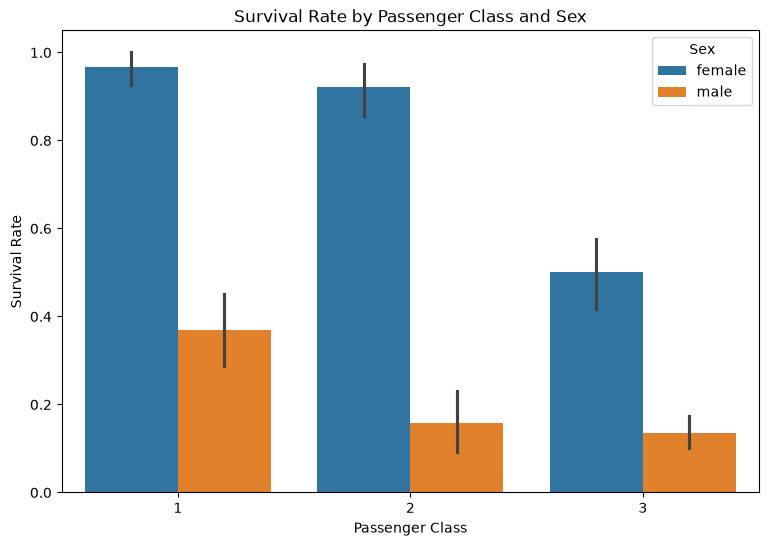

In [6]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

# 6. Numerical Feature Relationships

## Concept

Numerical feature relationships examine how several numerical variables are connected with each other.

For the Titanic dataset, important numerical variables include:

- Age
- Fare
- SibSp
- Parch
- Pclass

## Example

In a financial dataset, income, expenditure, savings, and loan amount can be analyzed together.

## Implementation

We will examine the correlation between selected numerical features.

## Output

The output will show the relationships between these numerical variables.

## Interpretation

Strong positive or negative values may indicate meaningful relationships, while values near zero may indicate weak linear relationships.

## Insight

This analysis helps identify features that may provide similar or different information.

## AI/ML Relevance

Understanding numerical feature relationships helps with feature engineering, feature selection, and preprocessing.

In [7]:
selected_features = ["Age", "Fare", "SibSp", "Parch", "Pclass"]

selected_correlation = df[selected_features].corr()

selected_correlation

,Age,Fare,SibSp,Parch,Pclass
Age,1.000000,0.096067,-0.308247,-0.189119,-0.369226
Fare,0.096067,1.000000,0.159651,0.216225,-0.549500
SibSp,-0.308247,0.159651,1.000000,0.414838,0.083081
Parch,-0.189119,0.216225,0.414838,1.000000,0.018443
Pclass,-0.369226,-0.549500,0.083081,0.018443,1.000000


# 7. Identifying Strong, Weak and Negative Correlations

## Concept

Correlation values can be used to classify relationships as strong, weak, positive, or negative.

A positive correlation means two variables generally move in the same direction.

A negative correlation means that one variable tends to decrease when the other increases.

A weak correlation indicates little or no strong linear relationship.

## Example

Income and spending may show a positive relationship, while price and demand may show a negative relationship.

## Implementation

We will examine the correlations of numerical features with the target variable, `Survived`.

## Output

The output will display how numerical variables are related to survival.

## Interpretation

Features with stronger correlations may have a more noticeable linear relationship with the target.

## Insight

Correlation is only one way to evaluate feature importance, so results should be interpreted together with other analyses.

## AI/ML Relevance

Features that show useful relationships with the target may be considered during model development and feature selection.

In [8]:
survival_correlation = correlation_matrix["Survived"].sort_values(
    ascending=False
)

print("Correlation with Survived:")
print(survival_correlation)

Correlation with Survived:
Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64


# 8. Potential Multicollinearity

## Concept

Multicollinearity occurs when two or more independent features are strongly correlated with each other.

This means that multiple features may contain similar information.

## Example

In a business dataset, annual income and monthly income may be highly correlated because they describe similar information.

## Implementation

We will inspect the correlation values between numerical input features.

## Output

The correlation matrix will help identify feature pairs with relatively strong relationships.

## Interpretation

Very high correlation between independent features may indicate potential multicollinearity.

## Insight

The Titanic dataset can be checked for highly related numerical features before building a model.

## AI/ML Relevance

Multicollinearity can affect some Machine Learning and statistical models, especially linear models. Highly correlated features may require further investigation or feature selection.

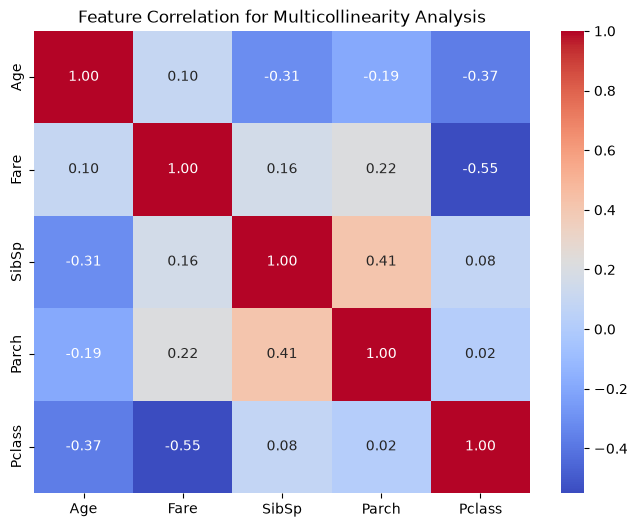

In [9]:
features = ["Age", "Fare", "SibSp", "Parch", "Pclass"]

feature_correlation = df[features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    feature_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation for Multicollinearity Analysis")
plt.show()

# 9. Feature Relationship: Family Members and Survival

## Concept

Multivariate analysis can also examine how related features work together.

In the Titanic dataset:

- `SibSp` represents siblings and spouses aboard.
- `Parch` represents parents and children aboard.

We can combine these features to understand the total number of family members travelling with a passenger and examine its relationship with survival.

## Example

In a customer dataset, the total number of products purchased may be created by combining purchases from different product categories.

## Implementation

We will create a new feature called `FamilySize` by combining `SibSp` and `Parch`.

## Output

The analysis will show the relationship between family size and survival.

## Interpretation

Different family sizes may show different average survival rates.

## Insight

Combining existing features can reveal relationships that may not be clearly visible when features are analyzed separately.

## AI/ML Relevance

Creating useful combined features is called feature engineering. Feature engineering can improve the information available to a Machine Learning model.

In [10]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

family_survival = df.groupby("FamilySize")["Survived"].mean()

print(family_survival)

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


# 10. Family Size vs Survival

## Concept

A visualization can help us understand how the relationship between family size and survival changes across different groups.

## Example

In a business dataset, customer purchase frequency can be compared with customer retention rate.

## Implementation

We will create a bar chart showing the average survival rate for each family size.

## Output

Each bar represents the average survival rate for a particular family size.

## Interpretation

Higher or lower bars indicate differences in survival probability across family-size groups.

## Insight

The relationship may reveal useful patterns involving passengers travelling alone or with different numbers of family members.

## AI/ML Relevance

This type of analysis can help identify useful engineered features for classification models.

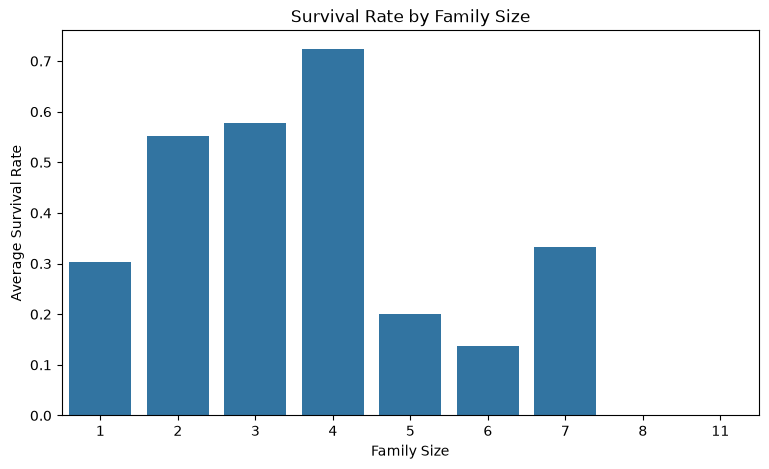

In [11]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Average Survival Rate")

plt.show()

# Conclusion

In this notebook, Multivariate Analysis was performed on the Titanic dataset to understand relationships among multiple variables.

The analysis included:

- Correlation Matrix
- Correlation Heatmap
- Pair Plot
- Multiple Feature Relationships
- Feature Interactions
- Numerical Feature Relationships
- Strong and Weak Correlations
- Negative Correlations
- Potential Multicollinearity
- Feature Engineering using Family Size

## Final Insight

Multivariate analysis provides a deeper understanding of how multiple variables interact with each other. It helps identify important relationships, feature interactions, correlated variables, and possible multicollinearity.

The analysis also showed how new features, such as `FamilySize`, can be created from existing features to explore additional patterns.

## AI/ML Relevance

Multivariate analysis is important before building a Machine Learning model because it helps with:

- Feature selection
- Feature engineering
- Identifying correlated features
- Understanding interactions
- Detecting potential multicollinearity
- Preparing meaningful input features for a model

Overall, this analysis provides a strong foundation for the next stages of Exploratory Data Analysis and Machine Learning.